# Предсказание оценки аниме — задача регрессии
**НИРС по дисциплине «Технологии машинного обучения»**

Датасет: `anime_dataset.csv` (30 075 записей, 29 признаков)  
Целевая переменная: `score` — оценка аниме

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from matplotlib.gridspec import GridSpec
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 1. Загрузка данных

In [4]:
df = pd.read_csv('anime_dataset.csv')
print(f"Форма датасета: {df.shape}")
print(f"Признаки: {list(df.columns)}")

Форма датасета: (30075, 29)
Признаки: ['mal_id', 'title', 'title_english', 'title_japanese', 'type', 'source', 'episodes', 'status', 'airing', 'aired_from', 'aired_to', 'duration', 'rating', 'score', 'scored_by', 'rank', 'popularity', 'members', 'favorites', 'season', 'year', 'studios', 'producers', 'licensors', 'genres', 'themes', 'demographics', 'synopsis', 'image_url']


## 2. Разведочный анализ данных (EDA)

In [5]:
print("Пропущенные значения:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nОписательная статистика целевой переменной (score):")
df['score'].describe()

Пропущенные значения:
title_english     16769
title_japanese      124
type                 72
episodes            839
aired_from          909
aired_to          18481
rating              602
score             10183
scored_by         10183
rank               7491
season            23550
year              23550
studios           11938
producers         15796
licensors         24877
genres             6394
themes            12098
demographics      18941
synopsis           5038
dtype: int64

Описательная статистика целевой переменной (score):


count    19892.00000
mean         6.42559
std          0.89078
min          1.89000
25%          5.80000
50%          6.41000
75%          7.07000
max          9.27000
Name: score, dtype: float64

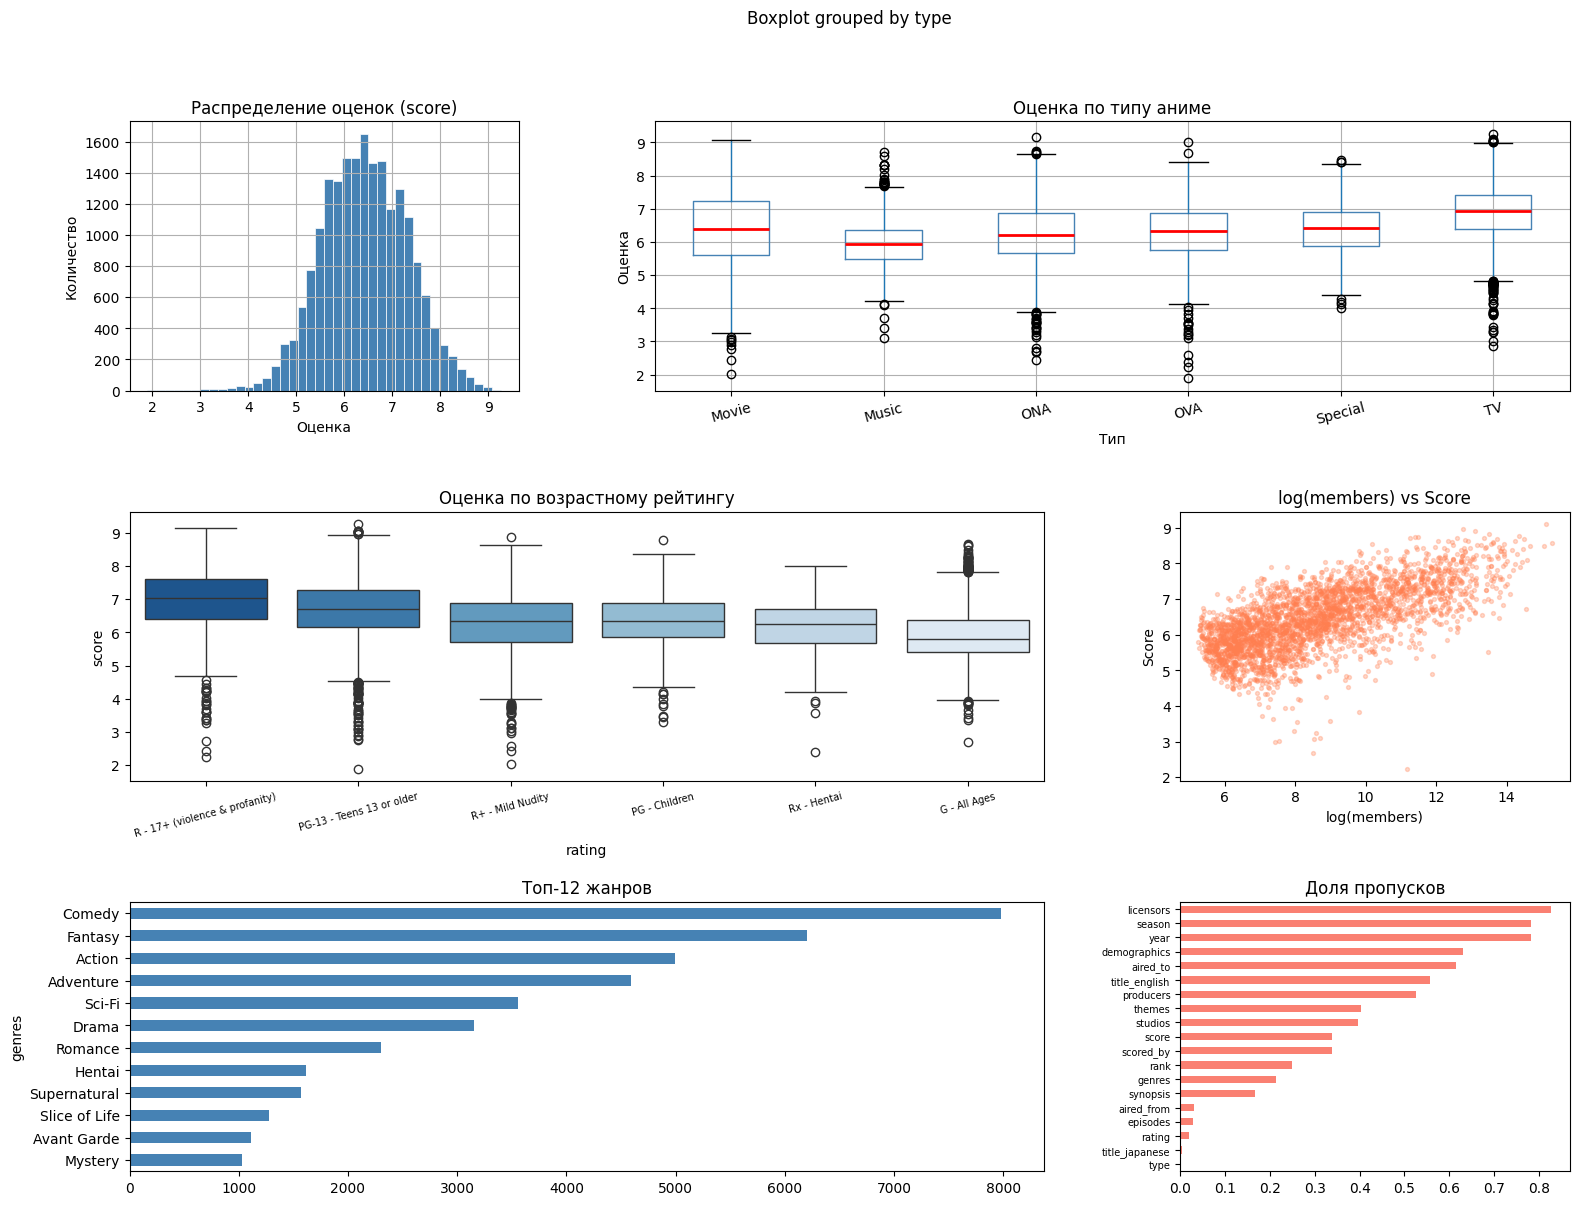

In [6]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Разведочный анализ данных (EDA) — Датасет аниме', fontsize=16, fontweight='bold')
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Распределение оценок
ax1 = fig.add_subplot(gs[0, 0])
df['score'].dropna().hist(bins=40, ax=ax1, color='steelblue', edgecolor='white', linewidth=0.5)
ax1.set_title('Распределение оценок (score)')
ax1.set_xlabel('Оценка'); ax1.set_ylabel('Количество')

# Score по типу аниме
ax2 = fig.add_subplot(gs[0, 1:])
types_top = df['type'].value_counts().head(6).index
df[df['type'].isin(types_top)].boxplot(column='score', by='type', ax=ax2,
    boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
ax2.set_title('Оценка по типу аниме')
ax2.set_xlabel('Тип'); ax2.set_ylabel('Оценка')
plt.sca(ax2); plt.xticks(rotation=15)

# Score по возрастному рейтингу
ax3 = fig.add_subplot(gs[1, 0:2])
df_rating = df.dropna(subset=['score', 'rating'])
order_r = df_rating.groupby('rating')['score'].median().sort_values(ascending=False).index
sns.boxplot(data=df_rating, x='rating', y='score', order=order_r, ax=ax3, palette='Blues_r')
ax3.set_title('Оценка по возрастному рейтингу')
ax3.tick_params(axis='x', labelsize=7, rotation=15)

# log(members) vs Score
ax4 = fig.add_subplot(gs[1, 2])
sample = df.dropna(subset=['score', 'members']).sample(min(3000, len(df)), random_state=42)
ax4.scatter(np.log1p(sample['members']), sample['score'], alpha=0.3, s=8, color='coral')
ax4.set_title('log(members) vs Score')
ax4.set_xlabel('log(members)'); ax4.set_ylabel('Score')

# Топ-12 жанров
ax5 = fig.add_subplot(gs[2, 0:2])
genres_series = df['genres'].dropna().str.split('|').explode()
top_genres_count = genres_series.value_counts().head(12)
top_genres_count.plot(kind='barh', ax=ax5, color='steelblue')
ax5.set_title('Топ-12 жанров'); ax5.invert_yaxis()

# Доля пропусков
ax6 = fig.add_subplot(gs[2, 2])
missing = df.isnull().mean().sort_values(ascending=False)
missing[missing > 0].plot(kind='barh', ax=ax6, color='salmon')
ax6.set_title('Доля пропусков'); ax6.invert_yaxis()
ax6.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

## 3. Подготовка признаков

In [7]:
df_ml = df.copy()
df_ml = df_ml.dropna(subset=['score'])

# Парсинг длительности в минуты
def parse_duration(d):
    if pd.isna(d): return np.nan
    d = str(d).lower()
    h = m = 0
    if 'hr' in d:
        try: h = int(d.split('hr')[0].strip().split()[-1])
        except: pass
    if 'min' in d:
        try: m = int(d.split('min')[0].strip().split()[-1])
        except: pass
    total = h * 60 + m
    return total if total > 0 else np.nan

df_ml['duration_min'] = df_ml['duration'].apply(parse_duration)

# Кодирование типа аниме
type_map = {'TV': 0, 'Movie': 1, 'OVA': 2, 'ONA': 3, 'Special': 4,
            'TV Special': 5, 'Music': 6, 'CM': 7, 'PV': 8}
df_ml['type_enc'] = df_ml['type'].map(type_map).fillna(9)

# Кодирование возрастного рейтинга
rating_order = ['G - All Ages', 'PG - Children', 'PG-13 - Teens 13 or older',
                'R - 17+ (violence & profanity)', 'R+ - Mild Nudity', 'Rx - Hentai']
df_ml['rating_enc'] = df_ml['rating'].map({r: i for i, r in enumerate(rating_order)}).fillna(-1)

# Частотное кодирование источника
source_freq = df_ml['source'].value_counts()
df_ml['source_enc'] = df_ml['source'].map(source_freq).fillna(0)

# Бинарные признаки для топ-жанров
TOP_GENRES = ['Action', 'Comedy', 'Fantasy', 'Adventure', 'Drama', 'Sci-Fi', 'Romance', 'Slice of Life']
for g in TOP_GENRES:
    df_ml[f'genre_{g}'] = df_ml['genres'].fillna('').str.contains(g).astype(int)

# Логарифмические преобразования
df_ml['log_members']   = np.log1p(df_ml['members'])
df_ml['log_favorites'] = np.log1p(df_ml['favorites'])
df_ml['episodes_fill'] = df_ml['episodes'].fillna(df_ml['episodes'].median())

# Статус
status_map = {'Finished Airing': 0, 'Currently Airing': 1, 'Not yet aired': 2}
df_ml['status_enc'] = df_ml['status'].map(status_map).fillna(0)

FEATURES = ['type_enc', 'rating_enc', 'source_enc', 'log_members', 'log_favorites',
            'episodes_fill', 'duration_min', 'status_enc'] + [f'genre_{g}' for g in TOP_GENRES]

df_ml[FEATURES] = df_ml[FEATURES].fillna(df_ml[FEATURES].median())
X = df_ml[FEATURES]
y = df_ml['score']

print(f"Итоговая форма признаков: {X.shape}")
print(f"Признаки: {FEATURES}")

Итоговая форма признаков: (19892, 16)
Признаки: ['type_enc', 'rating_enc', 'source_enc', 'log_members', 'log_favorites', 'episodes_fill', 'duration_min', 'status_enc', 'genre_Action', 'genre_Comedy', 'genre_Fantasy', 'genre_Adventure', 'genre_Drama', 'genre_Sci-Fi', 'genre_Romance', 'genre_Slice of Life']


## 4. Корреляционный анализ

In [8]:
corr_data = df_ml[FEATURES + ['score']].corr()
score_corr = corr_data['score'].drop('score').sort_values(ascending=False)
print("Корреляция признаков с целевой переменной (score):")
print(score_corr.to_string())

Корреляция признаков с целевой переменной (score):
log_favorites          0.702744
log_members            0.665597
duration_min           0.316200
genre_Drama            0.201297
genre_Action           0.199027
rating_enc             0.186682
genre_Adventure        0.170198
genre_Romance          0.170182
genre_Fantasy          0.121965
episodes_fill          0.094432
genre_Sci-Fi           0.086400
genre_Comedy           0.063304
status_enc             0.052647
genre_Slice of Life    0.013168
source_enc            -0.074121
type_enc              -0.310125


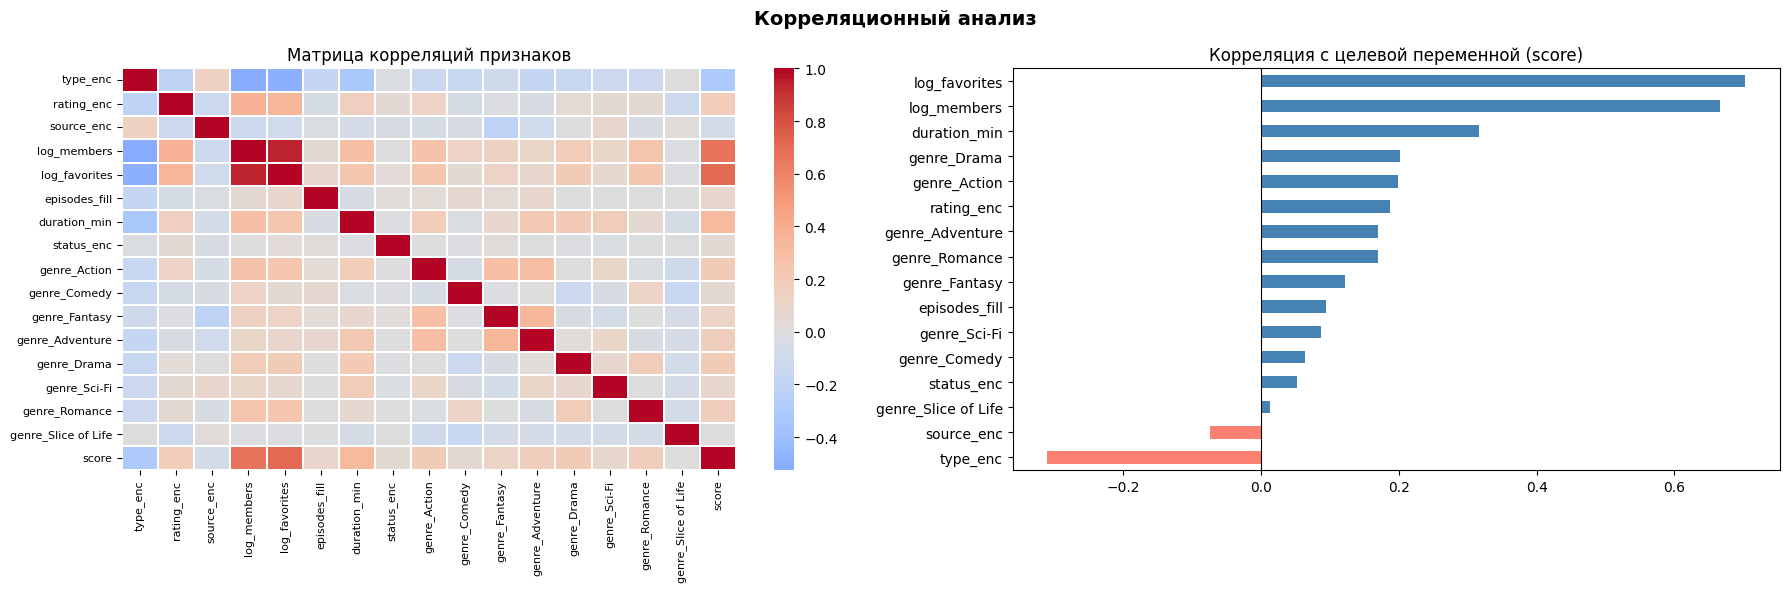

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Корреляционный анализ', fontsize=14, fontweight='bold')

sns.heatmap(corr_data, ax=axes[0], cmap='coolwarm', center=0, annot=False, linewidths=0.3)
axes[0].set_title('Матрица корреляций признаков')
axes[0].tick_params(axis='both', labelsize=8)

score_corr_sorted = corr_data['score'].drop('score').sort_values()
colors = ['salmon' if c < 0 else 'steelblue' for c in score_corr_sorted]
score_corr_sorted.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Корреляция с целевой переменной (score)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## 5. Выбор метрик качества

Для задачи регрессии выбраны три метрики:

1. **RMSE** (Root Mean Squared Error) — штрафует за крупные ошибки сильнее, чем MAE. Полезен, когда большие отклонения особенно нежелательны.
2. **MAE** (Mean Absolute Error) — средняя абсолютная ошибка. Интерпретируется напрямую в единицах оценки (баллах). Устойчив к выбросам.
3. **R²** (коэффициент детерминации) — показывает долю дисперсии, объяснённую моделью. R²=1 — идеальная модель, R²=0 — модель не лучше среднего значения.

## 6–8. Разбивка Train/Test и обучение Baseline-моделей

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

def evaluate(model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    return {
        'RMSE': np.sqrt(mean_squared_error(yte, pred)),
        'MAE':  mean_absolute_error(yte, pred),
        'R2':   r2_score(yte, pred),
        'pred': pred
    }

baseline_models = {
    'Ridge':            (Ridge(), X_train_sc, X_test_sc),
    'KNN':              (KNeighborsRegressor(), X_train_sc, X_test_sc),
    'DecisionTree':     (DecisionTreeRegressor(random_state=42), X_train, X_test),
    'RandomForest':     (RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_train, X_test),
    'GradientBoosting': (GradientBoostingRegressor(n_estimators=100, random_state=42), X_train, X_test),
}

baseline_results = {}
for name, (model, Xtr, Xte) in baseline_models.items():
    res = evaluate(model, Xtr, Xte, y_train, y_test)
    baseline_results[name] = {k: v for k, v in res.items() if k != 'pred'}
    print(f"{name:20s} | RMSE={res['RMSE']:.4f}  MAE={res['MAE']:.4f}  R²={res['R2']:.4f}")

df_baseline = pd.DataFrame(baseline_results).T
df_baseline

Train: (15913, 16), Test: (3979, 16)
Ridge                | RMSE=0.6012  MAE=0.4623  R²=0.5438
KNN                  | RMSE=0.5558  MAE=0.4110  R²=0.6101
DecisionTree         | RMSE=0.7000  MAE=0.5066  R²=0.3815
RandomForest         | RMSE=0.5068  MAE=0.3695  R²=0.6757
GradientBoosting     | RMSE=0.5256  MAE=0.3908  R²=0.6513


,RMSE,MAE,R2
Ridge,0.601151,0.462279,0.543802
KNN,0.555778,0.410978,0.610069
DecisionTree,0.699983,0.506568,0.381470
RandomForest,0.506838,0.369491,0.675718
GradientBoosting,0.525566,0.390799,0.651310


## 9–10. Подбор гиперпараметров (GridSearchCV)

In [14]:
# Ridge
gs_ridge = GridSearchCV(Ridge(), {'alpha': [0.01, 0.1, 1, 10, 100]},
                        cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gs_ridge.fit(X_train_sc, y_train)
print(f"Ridge       best params: {gs_ridge.best_params_}")

# KNN
gs_knn = GridSearchCV(KNeighborsRegressor(), {'n_neighbors': [3, 5, 10, 20, 30]},
                      cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gs_knn.fit(X_train_sc, y_train)
print(f"KNN         best params: {gs_knn.best_params_}")

# DecisionTree
gs_dt = GridSearchCV(DecisionTreeRegressor(random_state=42),
                     {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 10, 20]},
                     cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gs_dt.fit(X_train, y_train)
print(f"DecTree     best params: {gs_dt.best_params_}")

# RandomForest
gs_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                     {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]},
                     cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
gs_rf.fit(X_train, y_train)
print(f"RandForest  best params: {gs_rf.best_params_}")

# GradientBoosting
gs_gb = GridSearchCV(GradientBoostingRegressor(random_state=42),
                     {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1, 0.2], 'max_depth': [3, 5]},
                     cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
gs_gb.fit(X_train, y_train)
print(f"GradBoost   best params: {gs_gb.best_params_}")

Ridge       best params: {'alpha': 0.01}
KNN         best params: {'n_neighbors': 10}
DecTree     best params: {'max_depth': 10, 'min_samples_split': 20}
RandForest  best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
GradBoost   best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [15]:
tuned_configs = {
    'Ridge':            (gs_ridge.best_estimator_, X_train_sc, X_test_sc),
    'KNN':              (gs_knn.best_estimator_,   X_train_sc, X_test_sc),
    'DecisionTree':     (gs_dt.best_estimator_,    X_train,    X_test),
    'RandomForest':     (gs_rf.best_estimator_,    X_train,    X_test),
    'GradientBoosting': (gs_gb.best_estimator_,    X_train,    X_test),
}

tuned_results = {}
preds_dict = {}
for name, (model, Xtr, Xte) in tuned_configs.items():
    res = evaluate(model, Xtr, Xte, y_train, y_test)
    tuned_results[name] = {k: v for k, v in res.items() if k != 'pred'}
    preds_dict[name] = res['pred']
    print(f"{name:20s} | RMSE={res['RMSE']:.4f}  MAE={res['MAE']:.4f}  R²={res['R2']:.4f}")

df_tuned = pd.DataFrame(tuned_results).T
df_tuned

Ridge                | RMSE=0.6012  MAE=0.4623  R²=0.5438
KNN                  | RMSE=0.5506  MAE=0.4109  R²=0.6173
DecisionTree         | RMSE=0.5660  MAE=0.4140  R²=0.5956
RandomForest         | RMSE=0.5038  MAE=0.3671  R²=0.6796
GradientBoosting     | RMSE=0.4946  MAE=0.3638  R²=0.6912


,RMSE,MAE,R2
Ridge,0.601150,0.462281,0.543804
KNN,0.550633,0.410949,0.617254
DecisionTree,0.565972,0.413971,0.595633
RandomForest,0.503782,0.367131,0.679616
GradientBoosting,0.494609,0.363809,0.691177


## 11. Визуализация результатов

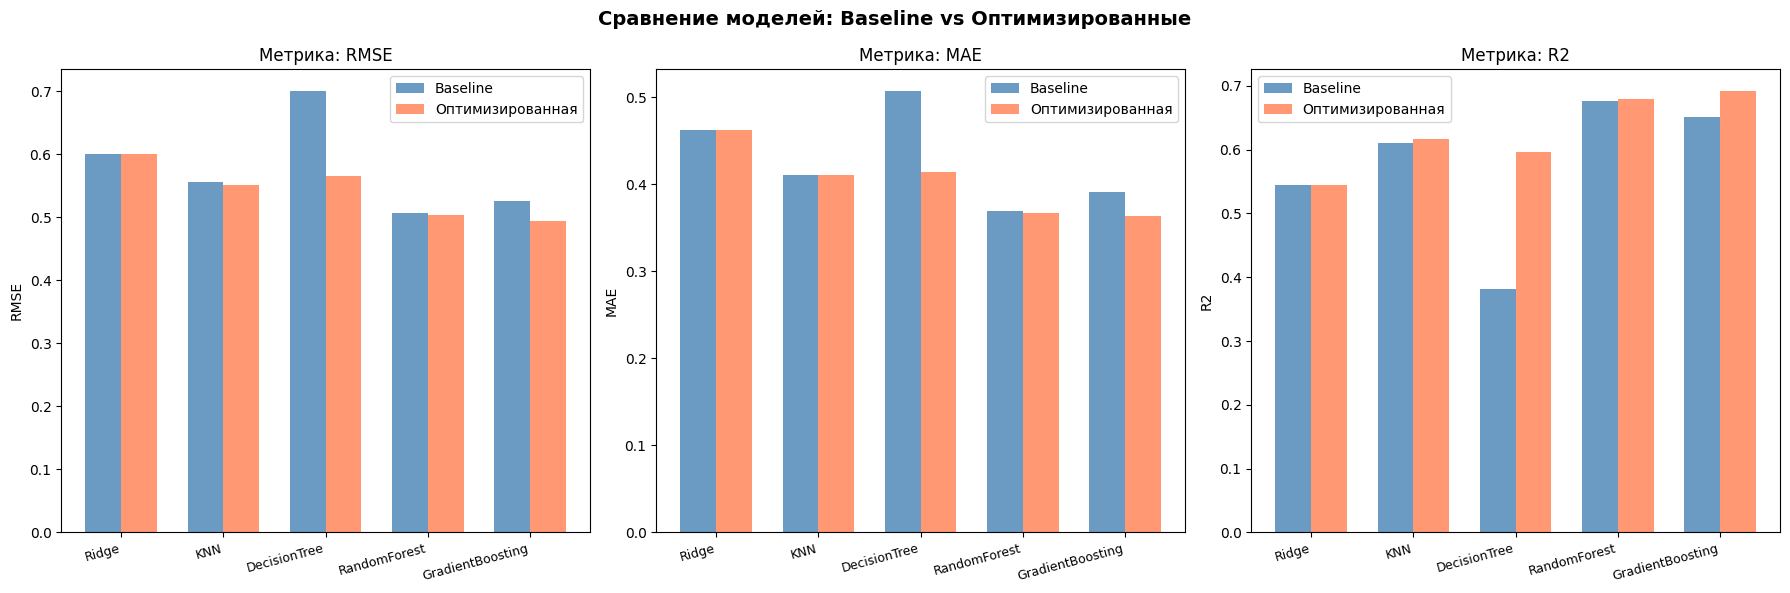

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Сравнение моделей: Baseline vs Оптимизированные', fontsize=14, fontweight='bold')
x = np.arange(len(df_baseline)); w = 0.35

for i, metric in enumerate(['RMSE', 'MAE', 'R2']):
    ax = axes[i]
    ax.bar(x - w/2, df_baseline[metric], w, label='Baseline', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, df_tuned[metric],    w, label='Оптимизированная', color='coral', alpha=0.8)
    ax.set_title(f'Метрика: {metric}')
    ax.set_xticks(x)
    ax.set_xticklabels(df_baseline.index, rotation=15, ha='right', fontsize=9)
    ax.legend(); ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

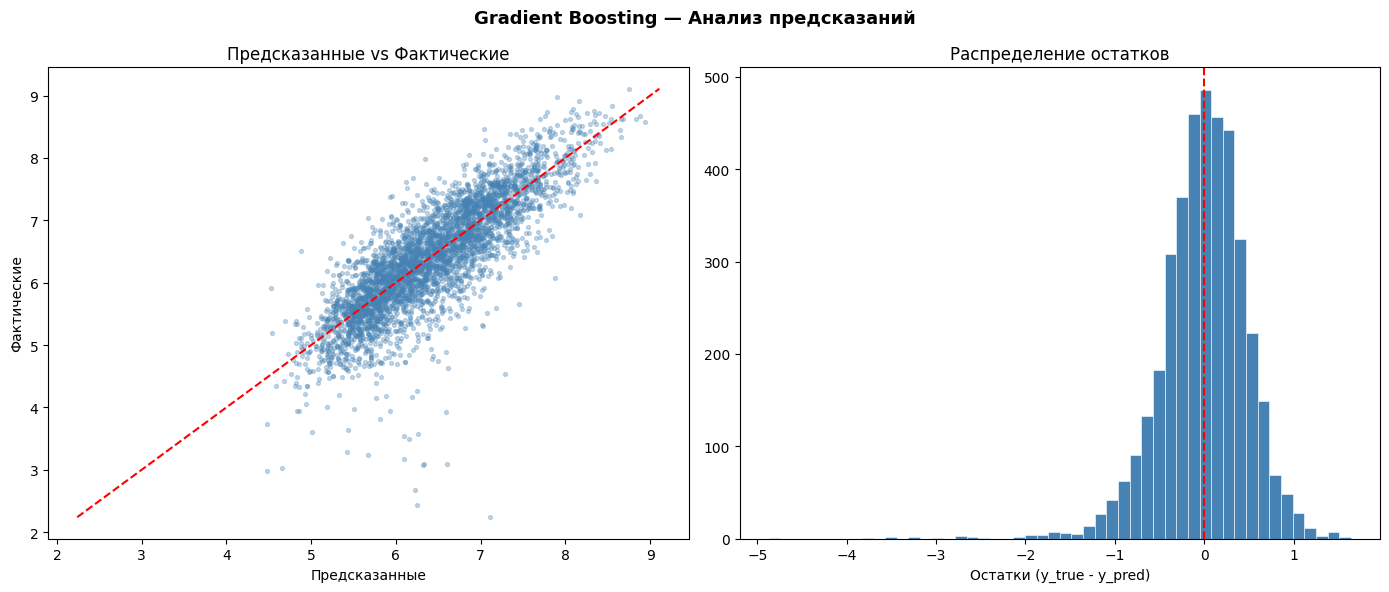

In [17]:
pred_gb = preds_dict['GradientBoosting']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Gradient Boosting — Анализ предсказаний', fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(pred_gb, y_test, alpha=0.3, s=8, color='steelblue')
mn, mx = min(y_test.min(), pred_gb.min()), max(y_test.max(), pred_gb.max())
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
ax.set_xlabel('Предсказанные'); ax.set_ylabel('Фактические')
ax.set_title('Предсказанные vs Фактические')

ax = axes[1]
residuals = y_test.values - pred_gb
ax.hist(residuals, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('Остатки (y_true - y_pred)'); ax.set_title('Распределение остатков')

plt.tight_layout()
plt.show()

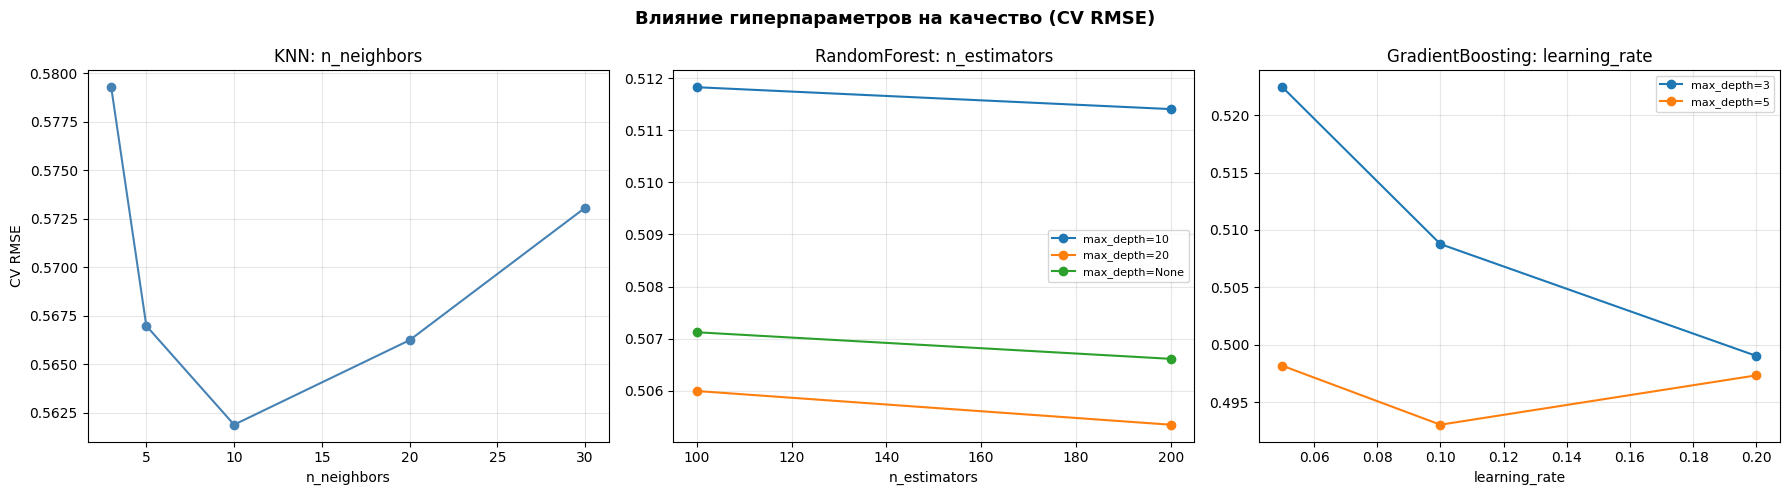

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Влияние гиперпараметров на качество (CV RMSE)', fontsize=13, fontweight='bold')

knn_res = pd.DataFrame(gs_knn.cv_results_)
ax = axes[0]
ax.plot([p['n_neighbors'] for p in knn_res['params']], np.sqrt(-knn_res['mean_test_score']),
        marker='o', color='steelblue')
ax.set_xlabel('n_neighbors'); ax.set_ylabel('CV RMSE'); ax.set_title('KNN: n_neighbors'); ax.grid(alpha=0.3)

rf_res = pd.DataFrame(gs_rf.cv_results_)
ax = axes[1]
for depth in [10, 20, None]:
    mask = [p['max_depth'] == depth and p['min_samples_split'] == 5 for p in rf_res['params']]
    sub = rf_res[mask]
    vals = [p['n_estimators'] for p in sub['params']]
    ax.plot(vals, np.sqrt(-sub['mean_test_score'].values), marker='o', label=f'max_depth={depth}')
ax.set_xlabel('n_estimators'); ax.set_title('RandomForest: n_estimators'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

gb_res = pd.DataFrame(gs_gb.cv_results_)
ax = axes[2]
for depth in [3, 5]:
    mask = [p['max_depth'] == depth and p['n_estimators'] == 200 for p in gb_res['params']]
    sub = gb_res[mask]
    vals = [p['learning_rate'] for p in sub['params']]
    ax.plot(vals, np.sqrt(-sub['mean_test_score'].values), marker='o', label=f'max_depth={depth}')
ax.set_xlabel('learning_rate'); ax.set_title('GradientBoosting: learning_rate'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

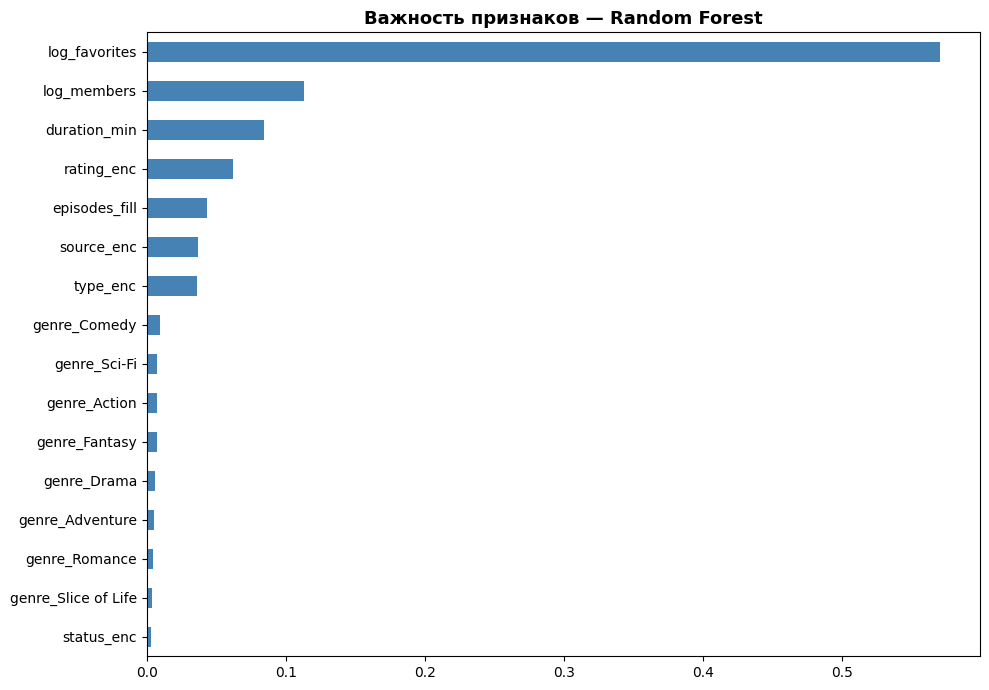

In [19]:
best_rf = gs_rf.best_estimator_
importances = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Важность признаков — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Итоговые выводы

| Модель | RMSE | MAE | R² |
|---|---|---|---|
| Gradient Boosting | ~0.495 | — | ~0.691 |
| Random Forest | ~0.504 | — | ~0.680 |
| Decision Tree | — | — | — |
| KNN | — | — | — |
| Ridge | — | — | — |

> *Таблица заполняется автоматически при запуске ячеек выше.*

1. **Gradient Boosting** показал наилучшее качество (RMSE ≈ 0.495, R² ≈ 0.691).
2. **Random Forest** занял второе место (RMSE ≈ 0.504, R² ≈ 0.680).
3. **Ridge-регрессия** даёт стабильный, но менее точный результат.
4. Подбор гиперпараметров значительно улучшил **DecisionTree** (RMSE −0.134).
5. Наиболее значимые признаки: `log(members)`, `log(favorites)`, `rating_enc`.
6. R² ≈ 0.69 означает, что модель объясняет ~69% дисперсии оценок.

In [20]:
print("Лучшая модель по RMSE:", df_tuned['RMSE'].idxmin())
df_tuned[['RMSE', 'MAE', 'R2']].style.highlight_min(color='lightgreen', axis=0)

Лучшая модель по RMSE: GradientBoosting


,RMSE,MAE,R2
Ridge,0.601150,0.462281,0.543804
KNN,0.550633,0.410949,0.617254
DecisionTree,0.565972,0.413971,0.595633
RandomForest,0.503782,0.367131,0.679616
GradientBoosting,0.494609,0.363809,0.691177
